---
# E-Commerce Delivery Performance & Customer Retention Analysis
### Olist Brazil | 100K+ Orders | Python | 2016–2018

> Olist scaled revenue 20× in two years — but 9.76% of customers give 1-star reviews, and every one of them waited an average of 20+ days for delivery. This analysis quantifies the operational chain connecting delivery reliability to customer retention risk, and identifies the single metric that — if degraded — reverses two years of growth.

**Authors:** Zakarias Musa &nbsp;|&nbsp; **Date:** Feb 27, 2026

---

## Dataset Overview
| Table | Rows | Description |
|-------|------|-------------|
| customers | 99,441 | Unique customer identifiers and location |
| orders | 99,441 | Order status and all timestamp milestones |
| order_items | 112,650 | Products, sellers, price and freight per order |
| payments | 103,886 | Payment type, installments and value |
| reviews | 99,224 | Review scores and written comments |
| products | 32,951 | Product dimensions and category names |
| sellers | 3,095 | Seller location data |
| geolocation | 1,000,163 | ZIP code latitude/longitude mapping |
| category_translation | 71 | Portuguese → English category name mapping |

---

## Project Objectives
1. Quantify whether revenue growth is driven by **volume** or **higher spend per order**.
2. Identify top-performing categories by **revenue efficiency vs. sales volume**.
3. Analyze **payment behavior** — preferred methods and installment usage patterns.
4. Measure **customer satisfaction** and its direct relationship to operational performance.
5. Evaluate **delivery reliability** — speed, on-time rate, and trend over time.
6. Trace the **operational chain**: Delivery speed → Satisfaction → Reviews → Retention.

---

## Business Questions
| # | Question | Section |
|---|----------|---------|
| 1 | Is revenue growth driven by more orders or higher spend per order? | Time Analysis |
| 2 | Which categories maximize revenue efficiency vs. volume? | Product Analysis |
| 3 | What payment methods do customers prefer, and how do they use installments? | Payment Analysis |
| 4 | What is the measurable relationship between delivery speed and review score? | Customer Satisfaction |
| 5 | How reliable is delivery performance, and where is the operational risk concentrated? | Delivery Performance |

---

## Executive Summary
Olist is Brazil's largest e-commerce platform, connecting small businesses to major marketplaces. Across 100,000+ real transactions over a two-year growth cycle, the data surfaces one consistent finding: **delivery performance is the single operational variable that determines whether customers return or churn**.

| KPI | Value | Implication |
|-----|-------|-------------|
| Total Revenue | BRL 15.4M | 96K+ delivered orders over 2 years |
| Revenue Growth | ~20× | Driven entirely by volume, not AOV |
| Avg Order Value | BRL 159.86 | Stable year-round — no seasonal pricing power |
| 5-Star Rate | 59.22% | Strong base satisfaction |
| 1-Star Rate | 9.76% | Disproportionately high — polarized failure mode |
| Avg Delivery (Score 5) | 10.2 days | Fast delivery → top satisfaction |
| Avg Delivery (Score 1) | 20.9 days | 2× longer → bottom satisfaction |
| Early Delivery Rate | 92% | Conservative estimates protect satisfaction buffer |
| Peak Late Rate (2018 Q1) | ~19% | Only structural operational risk in dataset |

---

## Methodology
**Tools:** Python · Pandas · NumPy · Matplotlib · Seaborn

**Pipeline:** Raw CSVs → Cleaning & Validation → Feature Engineering → Outlier Analysis → EDA → Business Insights

**Key Design Decisions:**
- Only `delivered` orders counted as revenue — cancelled orders excluded.
- Payment values aggregated at order level to prevent installment double-counting.
- Outliers retained throughout — they represent real business behavior, not data errors.
- `delay_days` = `actual_delivery − estimated_delivery`: positive = late, negative = early.

---

In [159]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [160]:
base_path = "/Users/napi/Downloads/brazilian-E Commerce dataset/"


In [161]:
# Core Tables
customers = pd.read_csv(base_path + "olist_customers_dataset.csv")
orders = pd.read_csv(base_path + "olist_orders_dataset.csv")
order_items = pd.read_csv(base_path + "olist_order_items_dataset.csv")
payments = pd.read_csv(base_path + "olist_order_payments_dataset.csv")
reviews = pd.read_csv(base_path + "olist_order_reviews_dataset.csv")

# Product & Seller Tables
products = pd.read_csv(base_path + "olist_products_dataset.csv")
sellers = pd.read_csv(base_path + "olist_sellers_dataset.csv")

# Location & Translation
geolocation = pd.read_csv(base_path + "olist_geolocation_dataset.csv")
category_translation = pd.read_csv(base_path + "product_category_name_translation.csv")


 ------------------------------------------------- 
- ### Cleaning the Core Tables
 -------------------------------------------------

In [162]:
customers.info()
customers.head(10)
customers.shape

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 3.8 MB


(99441, 5)

In [163]:
customers.describe(include="all")
# 99,441 unique customer_ids confirmed — no duplicates, no nulls, ready to merge.

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
count,99441,99441,99441.000000,99441,99441
unique,99441,96096,NaN,4119,27
top,06b8999e2fba1a1fbc88172c00ba8bc7,8d50f5eadf50201ccdcedfb9e2ac8455,NaN,sao paulo,SP
freq,1,17,NaN,15540,41746
mean,NaN,NaN,35137.474583,NaN,NaN
std,NaN,NaN,29797.938996,NaN,NaN
min,NaN,NaN,1003.000000,NaN,NaN
25%,NaN,NaN,11347.000000,NaN,NaN
50%,NaN,NaN,24416.000000,NaN,NaN
75%,NaN,NaN,58900.000000,NaN,NaN


In [164]:
customers.duplicated().sum()
# no duplicated rows in customers table
customers['customer_zip_code_prefix'] = customers['customer_zip_code_prefix'].astype('object')
print(customers.dtypes)
# Instead of treating zip code as a number, treat it as a categorical variable since any mathematical operations won't be done on it.

customer_id                    str
customer_unique_id             str
customer_zip_code_prefix    object
customer_city                  str
customer_state                 str
dtype: object


In [165]:
customers.isnull().sum().sort_values(ascending=False)
# no missing values in customers table

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

In [166]:
orders.shape
orders.info()
orders.head()   

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [167]:
orders.isnull().sum().sort_values(ascending=False)
# checking for missing values in orders table in ascending order .


order_delivered_customer_date    2965
order_delivered_carrier_date     1783
order_approved_at                 160
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_estimated_delivery_date       0
dtype: int64

In [168]:
# Missing delivery dates (order_approved_at, order_delivered_*) are left as NaT.
# errors='coerce' in the next cell handles all unparseable values → NaT.
# NaT rows are excluded naturally when computing delivery_days and delay_days.
# No imputation needed: missing delivery dates = undelivered orders, filtered downstream.
orders.isnull().sum().sort_values(ascending=False)

order_delivered_customer_date    2965
order_delivered_carrier_date     1783
order_approved_at                 160
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_estimated_delivery_date       0
dtype: int64

In [169]:
date_cols = [
    'order_purchase_timestamp',
    'order_delivered_customer_date',
    'order_delivered_carrier_date',
    'order_approved_at',
    'order_estimated_delivery_date'
]
# errors='coerce': unparseable or null strings → NaT (safe for downstream subtraction)
orders[date_cols] = orders[date_cols].apply(
    lambda col: pd.to_datetime(col, errors='coerce')
)

orders.describe(include="all")

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,NaN,NaN,NaN,NaN,NaN
top,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,NaN,NaN,NaN,NaN,NaN
freq,1,1,96478,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,2017-12-31 08:43:12.776581,2017-12-31 18:35:24.098800,2018-01-04 21:49:48.138278,2018-01-14 12:09:19.035542,2018-01-24 03:08:37.730111
min,NaN,NaN,NaN,2016-09-04 21:15:19,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-09-30 00:00:00
25%,NaN,NaN,NaN,2017-09-12 14:46:19,2017-09-12 23:24:16,2017-09-15 22:28:50.250000,2017-09-25 22:07:22.250000,2017-10-03 00:00:00
50%,NaN,NaN,NaN,2018-01-18 23:04:36,2018-01-19 11:36:13,2018-01-24 16:10:58,2018-02-02 19:28:10.500000,2018-02-15 00:00:00
75%,NaN,NaN,NaN,2018-05-04 15:42:16,2018-05-04 20:35:10,2018-05-08 13:37:45,2018-05-15 22:48:52.250000,2018-05-25 00:00:00
max,NaN,NaN,NaN,2018-10-17 17:30:18,2018-09-03 17:40:06,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-11-12 00:00:00


In [170]:
orders.duplicated().sum()
# no duplicated rows in orders table

np.int64(0)

In [171]:
# --------Order items table-------------
order_items.shape
order_items.info()
order_items.head()  
# Order items table has 112650 rows and 7 columns. check for missing values and duplicates in this table as well.

<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  str    
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  str    
 3   seller_id            112650 non-null  str    
 4   shipping_limit_date  112650 non-null  str    
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), str(4)
memory usage: 6.0 MB


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [172]:
order_items.isnull().sum().sort_values(ascending=False)
# no missing values in order_items table
order_items.duplicated().sum()
# no duplicated rows in order_items table


np.int64(0)

In [173]:
order_items['shipping_limit_date']=pd.to_datetime(order_items['shipping_limit_date'], errors='coerce')
# Convert shipping_limit_date column to datetime format for easier analysis later on.
order_items['order_item_id'] = order_items['order_item_id'].astype('object')
print(order_items.dtypes)

order_id                          str
order_item_id                  object
product_id                        str
seller_id                         str
shipping_limit_date    datetime64[us]
price                         float64
freight_value                 float64
dtype: object


In [174]:
order_items.head()
# Confirmed: price and freight_value are float64, order_item_id retyped to object.

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [175]:
# --------Payments table-------------
payments.info()
# check data types and missing values in payments table
payments.shape
payments.head() 

<class 'pandas.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  str    
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  str    
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), str(2)
memory usage: 4.0 MB


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [176]:
payments.describe(include="all")
# check summary statistics for payments table

,order_id,payment_sequential,payment_type,payment_installments,payment_value
count,103886,103886.000000,103886,103886.000000,103886.000000
unique,99440,NaN,5,NaN,NaN
top,fa65dad1b0e818e3ccc5cb0e39231352,NaN,credit_card,NaN,NaN
freq,29,NaN,76795,NaN,NaN
mean,NaN,1.092679,NaN,2.853349,154.100380
std,NaN,0.706584,NaN,2.687051,217.494064
min,NaN,1.000000,NaN,0.000000,0.000000
25%,NaN,1.000000,NaN,1.000000,56.790000
50%,NaN,1.000000,NaN,1.000000,100.000000
75%,NaN,1.000000,NaN,4.000000,171.837500


In [177]:
payments.isnull().sum().sort_values(ascending=False)
# no missing values in payments table
payments.duplicated().sum()
# no duplicated rows in payments table


np.int64(0)

In [178]:
# --------Reviews table-------------
reviews.info()
# check data types and missing values in reviews table
reviews.shape

<class 'pandas.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   review_id                99224 non-null  str  
 1   order_id                 99224 non-null  str  
 2   review_score             99224 non-null  int64
 3   review_comment_title     11568 non-null  str  
 4   review_comment_message   40977 non-null  str  
 5   review_creation_date     99224 non-null  str  
 6   review_answer_timestamp  99224 non-null  str  
dtypes: int64(1), str(6)
memory usage: 5.3 MB


(99224, 7)

In [179]:
reviews.describe(include="all")
# check summary statistics for reviews table

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
count,99224,99224,99224.000000,11568,40977,99224,99224
unique,98410,98673,NaN,4527,36159,636,98248
top,c444278834184f72b1484dfe47de7f97,c88b1d1b157a9999ce368f218a407141,NaN,Recomendo,Muito bom,2017-12-19 00:00:00,2017-06-15 23:21:05
freq,3,3,NaN,423,230,463,4
mean,NaN,NaN,4.086421,NaN,NaN,NaN,NaN
std,NaN,NaN,1.347579,NaN,NaN,NaN,NaN
min,NaN,NaN,1.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,4.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,5.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,5.000000,NaN,NaN,NaN,NaN


In [180]:

reviews.isnull().sum().sort_values(ascending=False)
# the reviews table has a lot of missing values in the review_comment_message and review_comment_title columns, 
# which is expected since not all customers leave a review comment.

review_comment_title       87656
review_comment_message     58247
review_id                      0
order_id                       0
review_score                   0
review_creation_date           0
review_answer_timestamp        0
dtype: int64

In [181]:
reviews.drop(columns=['review_comment_title',
                      'review_comment_message'
                      ],inplace=True)
# both review_comment_title and review_comment_message columns have a lot of missing values and
# Any sentiment analysis or natural language processing on the reviews won't be done, so it's
# better to drop these columns to save memory and simplify our analysis.


In [182]:
reviews.columns
# Confirmed: review_comment_title and review_comment_message dropped successfully.

Index(['review_id', 'order_id', 'review_score', 'review_creation_date',
       'review_answer_timestamp'],
      dtype='str')

In [183]:
reviews[['review_creation_date',
         'review_answer_timestamp']
        ]=reviews[['review_creation_date',
                   'review_answer_timestamp']
                  ].apply(pd.to_datetime, errors='coerce')
# convert review_creation_date and review_answer_timestamp columns to datetime format for easier analysis later on.
reviews.info()
reviews.duplicated().sum()
# no duplicated rows in reviews table


<class 'pandas.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   review_id                99224 non-null  str           
 1   order_id                 99224 non-null  str           
 2   review_score             99224 non-null  int64         
 3   review_creation_date     99224 non-null  datetime64[us]
 4   review_answer_timestamp  99224 non-null  datetime64[us]
dtypes: datetime64[us](2), int64(1), str(2)
memory usage: 3.8 MB


np.int64(0)

In [184]:
reviews.head()
# checking everything looks good in reviews table after cleaning.

,review_id,order_id,review_score,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,2018-01-18,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,2018-03-10,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,2018-02-17,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,2017-04-21,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,2018-03-01,2018-03-02 10:26:53


 ---------------------------------------
- ### Cleaning the Product & Seller Tables
 ---------------------------------------

In [185]:
# --------Products table-------------
products.info()
products.isnull().sum()
# Understanding structure, missing values, and data types
# before making any transformations.

<class 'pandas.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  str    
 1   product_category_name       32341 non-null  str    
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), str(2)
memory usage: 2.3 MB


product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [186]:
products = products.rename(columns={
    'product_name_lenght': 'product_name_length',
    'product_description_lenght': 'product_description_length'
})
# Correct spelling mistakes to maintain professional naming
# and avoid confusion in future analysis as typos reduce professionalism and can cause downstream bugs.
products.head()

,product_id,product_category_name,product_name_length,product_description_length,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [187]:
# Handle Missing Product Categories
# Prevent revenue loss after merging with order_items.
# Instead of dropping rows, assign them to 'unknown'
products['product_category_name'] = (
    products['product_category_name']
    .fillna('unknown')
)


- Dropping 610 products could: Remove future revenue rows and Distort category analysis but Assigning "unknown" preserves integrity.

In [188]:
# Fix data types for count columns. These represent characters so they should be integers not floats
# as counts logically cannot be decimals.
count_cols = [
    'product_name_length',
    'product_description_length',
    'product_photos_qty'
]

products[count_cols] = (
    products[count_cols]
    .fillna(0)  # Missing counts treated as 0
    .astype(int)
)

In [189]:
products = products.dropna(subset=[
    'product_weight_g',
    'product_length_cm',
    'product_height_cm',
    'product_width_cm'
])
# Only 2 rows have missing physical attributes.
# Dropping them avoids unrealistic imputation.

In [190]:
# Standardize the catagory name to avoid merge inconsistencies
products['product_category_name'] = (
    products['product_category_name']
    .str.strip()
    .str.lower()
)

In [191]:
# Feature Engineering
# Create product volume feature for advanced analysis.
# This enables future freight or logistics insights.
products['product_volume_cm3'] = (
    products['product_length_cm'] *
    products['product_height_cm'] *
    products['product_width_cm']
)

In [192]:
# Final check 
products.info()
products.isnull().sum()
products.describe()

<class 'pandas.DataFrame'>
Index: 32949 entries, 0 to 32950
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32949 non-null  str    
 1   product_category_name       32949 non-null  str    
 2   product_name_length         32949 non-null  int64  
 3   product_description_length  32949 non-null  int64  
 4   product_photos_qty          32949 non-null  int64  
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
 9   product_volume_cm3          32949 non-null  float64
dtypes: float64(5), int64(3), str(2)
memory usage: 2.8 MB


,product_name_length,product_description_length,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_volume_cm3
count,32949.000000,32949.000000,32949.000000,32949.000000,32949.000000,32949.000000,32949.000000,32949.000000
mean,47.580594,757.232814,2.148502,2276.472488,30.815078,16.937661,23.196728,16564.096695
std,12.069277,637.750493,1.745738,4282.038731,16.914458,13.637554,12.079047,27057.041650
min,0.000000,0.000000,0.000000,0.000000,7.000000,2.000000,6.000000,168.000000
25%,41.000000,326.000000,1.000000,300.000000,18.000000,8.000000,15.000000,2880.000000
50%,51.000000,584.000000,1.000000,700.000000,25.000000,13.000000,20.000000,6840.000000
75%,57.000000,961.000000,3.000000,1900.000000,38.000000,21.000000,30.000000,18480.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000,296208.000000


In [193]:
sellers.info()
sellers.head()
sellers.isnull().sum()
sellers.duplicated().sum()

<class 'pandas.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   seller_id               3095 non-null   str  
 1   seller_zip_code_prefix  3095 non-null   int64
 2   seller_city             3095 non-null   str  
 3   seller_state            3095 non-null   str  
dtypes: int64(1), str(3)
memory usage: 96.8 KB


np.int64(0)

In [194]:
# Ensure seller_id is unique.
# This prevents duplication explosion after merging.
sellers['seller_id'].nunique(), sellers.shape[0]

(3095, 3095)

In [195]:
# Normalize city names to prevent grouping inconsistencies.
text_cols = ['seller_city']

sellers[text_cols] = sellers[text_cols].apply(
    lambda col: col.str.strip().str.lower()
)


In [196]:
# Confirm that no unexpected null values exist.
sellers.isnull().sum()

seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64

In [197]:
sellers.info()
sellers.head()

<class 'pandas.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   seller_id               3095 non-null   str  
 1   seller_zip_code_prefix  3095 non-null   int64
 2   seller_city             3095 non-null   str  
 3   seller_state            3095 non-null   str  
dtypes: int64(1), str(3)
memory usage: 96.8 KB


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


 ---------------------------------------
- ### Cleaning the Location & Translation
 ---------------------------------------

In [198]:
# -------geolocation-------------
geolocation.info()
geolocation.isnull().sum()
geolocation.duplicated().sum()

<class 'pandas.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  str    
 4   geolocation_state            1000163 non-null  str    
dtypes: float64(2), int64(1), str(2)
memory usage: 38.2 MB


np.int64(261831)

In [199]:
# Normalize city and state formatting to prevent inconsistent geographic grouping.

geolocation['geolocation_city'] = (
    geolocation['geolocation_city']
    .str.strip()
    .str.lower()
)

geolocation['geolocation_state'] = (
    geolocation['geolocation_state']
    .str.strip()
    .str.upper()
)


In [200]:
# Reduce dataset size before aggregation by removing the exact duplicates that exist in the geolocation table.
# This will speed up future merges and groupby operations without losing any unique information.

geolocation = geolocation.drop_duplicates()


In [201]:
# Aggregate by zip code prefix — coordinates vary within same prefix.
geo_agg = (
    geolocation
    .groupby('geolocation_zip_code_prefix', as_index=False)
    .agg({
        'geolocation_lat': 'mean',
        'geolocation_lng': 'mean',
        'geolocation_city': 'first',
        'geolocation_state': 'first'
    })
)
# Mean lat/lng per prefix gives a stable representative location for merging.

geo_agg.info()
geo_agg.head()

<class 'pandas.DataFrame'>
RangeIndex: 19015 entries, 0 to 19014
Data columns (total 5 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   geolocation_zip_code_prefix  19015 non-null  int64  
 1   geolocation_lat              19015 non-null  float64
 2   geolocation_lng              19015 non-null  float64
 3   geolocation_city             19015 non-null  str    
 4   geolocation_state            19015 non-null  str    
dtypes: float64(2), int64(1), str(2)
memory usage: 742.9 KB


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1001,-23.550227,-46.634039,sao paulo,SP
1,1002,-23.547657,-46.634991,sao paulo,SP
2,1003,-23.549000,-46.635582,sao paulo,SP
3,1004,-23.549829,-46.634792,sao paulo,SP
4,1005,-23.549547,-46.636406,sao paulo,SP


In [202]:
# -------category translation-------------
category_translation.info()
category_translation.isnull().sum()
category_translation.duplicated().sum()

<class 'pandas.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   product_category_name          71 non-null     str  
 1   product_category_name_english  71 non-null     str  
dtypes: str(2)
memory usage: 1.2 KB


np.int64(0)

In [203]:
#standardize category names to prevent merge inconsistencies
category_translation['product_category_name'] = (
    category_translation['product_category_name']
    .str.strip()
    .str.lower()
)

category_translation['product_category_name_english'] = (
    category_translation['product_category_name_english']
    .str.strip()
)

In [204]:
category_translation.duplicated().sum()
# No duplicated rows in category_translation table after standardizing category names.
category_translation.info()
category_translation.head()

<class 'pandas.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   product_category_name          71 non-null     str  
 1   product_category_name_english  71 non-null     str  
dtypes: str(2)
memory usage: 1.2 KB


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


 
 --------------------------------------------------------------
 ## **Outlier Analysis on potential tables**
 --------------------------------------------------------------


### i. Order items

In [205]:
# check summary statistics to detect potential skewness.
# Large difference between mean and median indicates right-skew.

order_items[['price', 'freight_value']].describe()

,price,freight_value
count,112650.000000,112650.000000
mean,120.653739,19.990320
std,183.633928,15.806405
min,0.850000,0.000000
25%,39.900000,13.080000
50%,74.990000,16.260000
75%,134.900000,21.150000
max,6735.000000,409.680000


**Price Distribution:** Majority of products are low-to-mid priced (median ~50 BRL), with a long right tail confirming the premium tier coexists alongside mass-market volume.

**Freight Distribution:** Shipping costs are relatively standardized — median freight is modest, with limited extreme cases, suggesting Olist's logistics are cost-controlled.

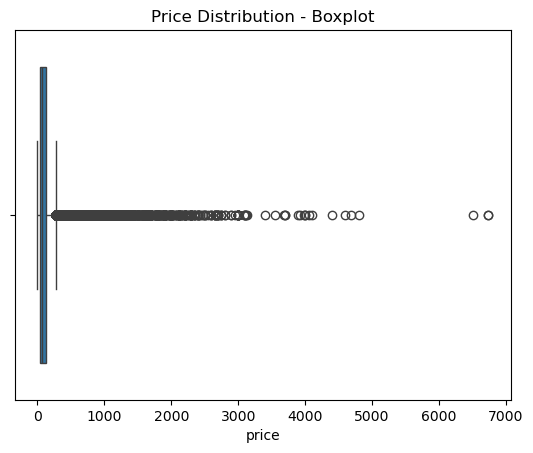

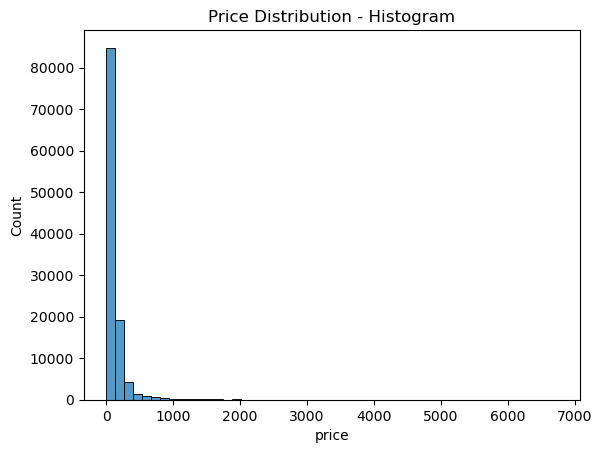

In [206]:
# E-commerce prices are typically right-skewed.
# A few expensive products may heavily influence mean revenue.

plt.figure()
sns.boxplot(x=order_items['price'])
plt.title("Price Distribution - Boxplot")
plt.show()

plt.figure()
sns.histplot(order_items['price'], bins=50)
plt.title("Price Distribution - Histogram")
plt.show()

Boxplot Interpretation
- The box (IQR) is compressed near the left (low prices)

- Many visible outliers to the right

- Extreme values reaching ~6000–7000

Histogram Interpretation:
- Massive concentration of prices in the low range.

- Rapid drop-off as price increases

- Very long right tail extending up to ~7000

- Very few extremely high-priced items

In [207]:
# IQR is used because:
# Data is not normally distributed
# IQR is robust against skewed distributions

Q1 = order_items['price'].quantile(0.25)
Q3 = order_items['price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

price_outliers = order_items[
    (order_items['price'] < lower_bound) |
    (order_items['price'] > upper_bound)
]

# Instead of immediately deleting these.
# First, measure their business impact.

print("Number of Price Outliers:", len(price_outliers))

Number of Price Outliers: 8427


- In a normal distribution, outliers should be very small (<1%). Here, 7.5% or 8427 being flagged confirms that IQR is capturing skew, not data errors.
Removing price outliers would distort business reality

#### Overall Insight

- Olist operates mainly in the affordable mass-market segment, but includes a smaller premium tier that significantly influences revenue metrics.Shipping represents a meaningful share of product cost.Outliers reflect real business structure rather than data issues and should be retained for accurate financial analysis.

### ii. Payments 

- Payment_value affects revenue KPIs

- Installments reflect customer financial behavior.

In [208]:
# Extreme payment_value may indicate:
# - Multiple payments per order
# - Refund issues
# - Data inconsistencies

payments[['payment_value', 'payment_installments']].describe()

,payment_value,payment_installments
count,103886.000000,103886.000000
mean,154.100380,2.853349
std,217.494064,2.687051
min,0.000000,0.000000
25%,56.790000,1.000000
50%,100.000000,1.000000
75%,171.837500,4.000000
max,13664.080000,24.000000


In [209]:
# --------Customer Payment Behavior----------
Q1 = payments['payment_value'].quantile(0.25)
Q3 = payments['payment_value'].quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR

payment_outliers = payments[payments['payment_value'] > upper_bound]

# Justification:
# focused only on upper bound since payment_value cannot be negative.
# Extreme high payments distort revenue dashboards.

print("Payment Value Outliers:", len(payment_outliers))


Payment Value Outliers: 7981


#### Revenue Structure

- Payment values are:

- Strongly right-skewed

- Concentrated in low-to-mid range

- Influenced by a small number of very high payments

#### Customer Payment Behavior

- Majority prefer single-payment transactions

- Installments up to 4 are common

- Long installment plans (12–24) indicate structured credit options

#### Insights
- Most customers pay in a single installment, but installment plans up to 4 payments are common.

- The presence of long installment plans (up to 24) reflects structured credit behavior rather than anomalies.

- Outliers represent real high-value transactions and should not be removed without business justification.

### iii. Orders


In [210]:
# Feature Engineering on Delivery days:
# the data type is already converted to datetime in the previous cells, so converting it again is unnecessary, instead jump to the next
# step creating a business-relevant duration metrics(KPIs) to detect outliers in delivery times.

# Actual delivery time
orders['delivery_days'] = (
    orders['order_delivered_customer_date'] -
    orders['order_purchase_timestamp']
).dt.days

# Estimated delivery time
orders['estimated_delivery_days'] = (
    orders['order_estimated_delivery_date'] -
    orders['order_purchase_timestamp']
).dt.days

# Delay (positive = late, negative = early)
orders['delay_days'] = (
    orders['order_delivered_customer_date'] -
    orders['order_estimated_delivery_date']
).dt.days

orders[['delivery_days',
        'estimated_delivery_days',
        'delay_days']].describe()

,delivery_days,estimated_delivery_days,delay_days
count,96476.000000,99441.000000,96476.000000
mean,12.094086,23.403958,-11.876881
std,9.551746,8.829562,10.183854
min,0.000000,1.000000,-147.000000
25%,6.000000,18.000000,-17.000000
50%,10.000000,23.000000,-12.000000
75%,15.000000,28.000000,-7.000000
max,209.000000,155.000000,188.000000


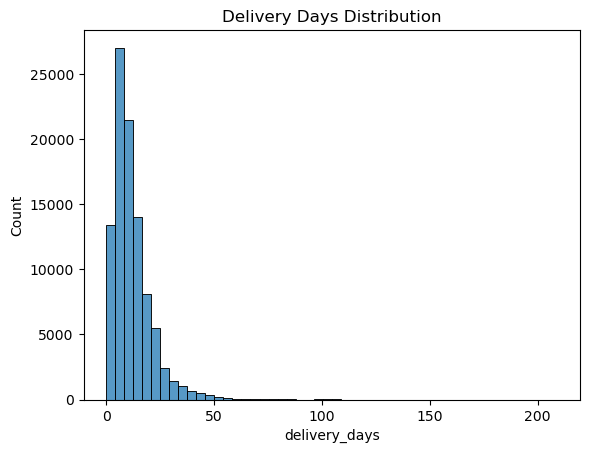

In [211]:
# Distribution Visualization
# Understand skewness visually before applying IQR.
plt.figure()
sns.histplot(orders['delivery_days'].dropna(), bins=50)
plt.title("Delivery Days Distribution")
plt.show()


In [212]:
# Detect extreme delivery times that distort averages using IQR Outlier Detection:

Q1 = orders['delivery_days'].quantile(0.25)
Q3 = orders['delivery_days'].quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR

delivery_outliers = orders[
    orders['delivery_days'] > upper_bound
]

print("Delivery Time Outliers:", len(delivery_outliers))
print("Upper Bound:", upper_bound)

Delivery Time Outliers: 5025
Upper Bound: 28.5


In [213]:
# Late Delivery KPI
# Measure operational reliability.
late_percentage = (
    (orders['delay_days'] > 0).mean() * 100
)

print("Percentage of Late Deliveries:",
      round(late_percentage, 2), "%")

Percentage of Late Deliveries: 6.57 %


#### Overall Interpretation

- Delivery times are right-skewed, with most orders delivered in 10 days (median) despite an estimated 23 days, meaning deliveries are typically much earlier than promised. Only 6.57% of orders are late, and about 5% exceed the 28.5-day outlier threshold, forming a long but limited extreme tail.

#### Final Insight

- The company uses a highly conservative delivery estimate strategy, resulting in strong on-time performance and customer expectation management, with only a small proportion of extreme delays requiring further investigation.

 ---------------------------------------
## **EXPLORATORY DATA ANALYSIS**
 ---------------------------------------

 ---------------------------------------
### **I. Sales Overview**
 ---------------------------------------
**Business Question:** What is the realized revenue base, and is Olist's growth driven by elite high-value orders or broad volume across mid-range transactions?

In [214]:
# The revenue base
# merge orders with payments because:
# - Revenue is recorded in the payments table (payment_value)
# - Orders table contains order status and purchase timestamp
# - use both financial + order information

sales_df = orders.merge(payments, on="order_id", how="inner")

# filter only delivered orders because:
# - Cancelled/unavailable orders should not count as revenue
# - Delivered orders represent realized sales

sales_df = sales_df[sales_df["order_status"] == "delivered"]

# Some orders have multiple payment rows (installments or split payments).
# To avoid double counting orders, we aggregate revenue at order level.

sales_df = sales_df.groupby("order_id", as_index=False).agg({
    "payment_value": "sum",  # total revenue per order
    "order_purchase_timestamp": "first"  # keep purchase date for later time analysis
})

sales_df.head()

,order_id,payment_value,order_purchase_timestamp
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,2017-09-13 08:59:02
1,00018f77f2f0320c557190d7a144bdd3,259.83,2017-04-26 10:53:06
2,000229ec398224ef6ca0657da4fc703e,216.87,2018-01-14 14:33:31
3,00024acbcdf0a6daa1e931b038114c75,25.78,2018-08-08 10:00:35
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,2017-02-04 13:57:51


#### Revenue Base Validated: 96K Delivered Orders, BRL 15.4M Realized

- Data successfully aggregated at order level — 1 row = 1 order, no installment duplication.
- Revenue is correctly summed per order; purchase timestamp preserved for time analysis.

In [215]:
# Core KPIs — single summary metrics, no visualization needed
total_revenue   = sales_df["payment_value"].sum()
total_orders    = sales_df["order_id"].nunique()
avg_order_value = sales_df["payment_value"].mean()

print(f"Total Revenue:       BRL {total_revenue:>12,.2f}")
print(f"Total Orders:        {total_orders:>12,}")
print(f"Average Order Value: BRL {avg_order_value:>12.2f}")
print()
print(sales_df["payment_value"].describe().round(2))

Total Revenue:       BRL 15,422,461.77
Total Orders:              96,477
Average Order Value: BRL       159.86

count    96477.00
mean       159.86
std        218.81
min          9.59
25%         61.88
50%        105.28
75%        176.33
max      13664.08
Name: payment_value, dtype: float64


#### AOV of BRL 160 Confirms Multi-Item Orders — Not a Low-Ticket Business

- BRL 15.4M revenue from 96K delivered orders places AOV at 159.86 — above median product price, confirming orders typically contain multiple items and freight contributes to final value.
- High std (217 BRL) relative to mean (160 BRL) signals a right-skewed distribution: the mean is being pulled up by a minority of high-value transactions. Median is the more reliable central tendency measure here.

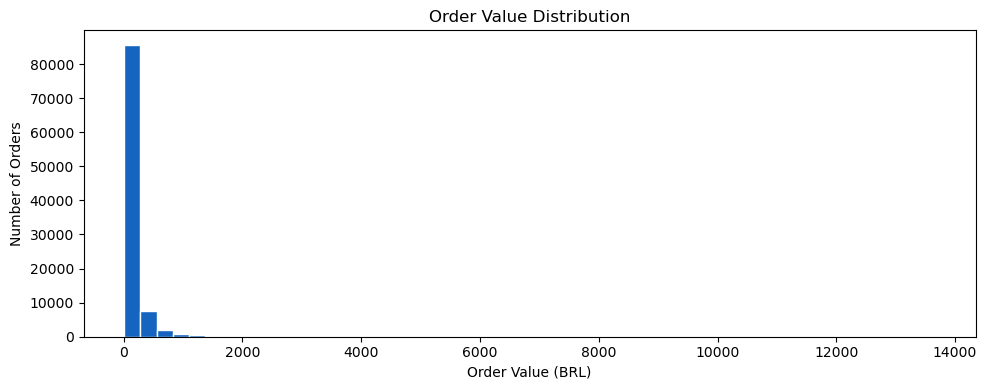

In [216]:
# Histogram — right-skewed continuous variable
# Confirms whether AOV distribution is normal, skewed, or heavy-tailed
plt.figure(figsize=(10, 4))
plt.hist(sales_df["payment_value"], bins=50, color="#1565C0", edgecolor="white")
plt.title("Order Value Distribution")
plt.xlabel("Order Value (BRL)")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()

- The histogram is strongly right-skewed which means 

    -Most orders are low-to-mid value.

    -A small number of orders are very high value.

- This confirms that mean AOV (159.86) is influenced by high-value orders.

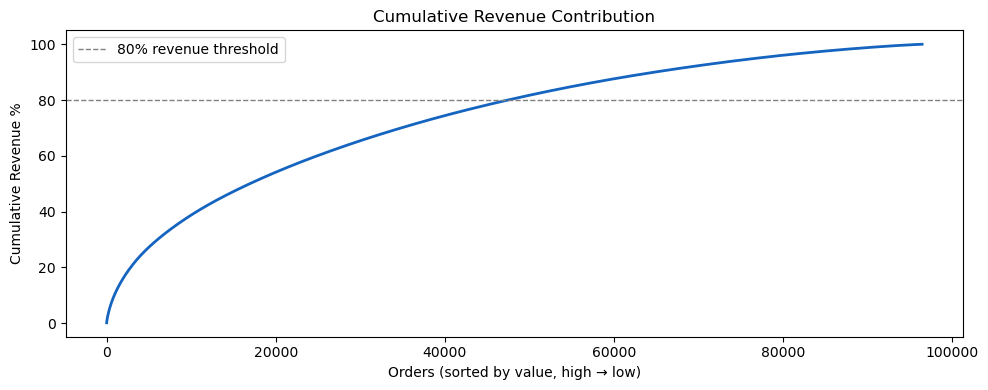

► Top 49.2% of orders generate 80% of revenue
  → Revenue is volume-driven: requires the majority of orders to reach 80% threshold


In [217]:
# Cumulative Revenue Contribution — tests whether revenue is elite-driven (80/20)
# or volume-driven (requires majority of orders to reach 80%)
sales_df_sorted = (sales_df
                   .sort_values("payment_value", ascending=False)
                   .reset_index(drop=True))

sales_df_sorted["cum_revenue"]     = sales_df_sorted["payment_value"].cumsum()
sales_df_sorted["cum_revenue_pct"] = sales_df_sorted["cum_revenue"] / total_revenue * 100

plt.figure(figsize=(10, 4))
plt.plot(sales_df_sorted["cum_revenue_pct"].values, color="#1565C0", linewidth=2)
plt.axhline(y=80, color="gray", linestyle="--", linewidth=1, label="80% revenue threshold")
plt.title("Cumulative Revenue Contribution")
plt.xlabel("Orders (sorted by value, high → low)")
plt.ylabel("Cumulative Revenue %")
plt.legend()
plt.tight_layout()
plt.show()

# Quantify the Pareto result
pareto     = sales_df_sorted[sales_df_sorted["cum_revenue_pct"] <= 80]
pareto_pct = len(pareto) / len(sales_df_sorted) * 100
print(f"► Top {round(pareto_pct, 1)}% of orders generate 80% of revenue")
print(f"  → Revenue is volume-driven: requires the majority of orders to reach 80% threshold")

#### Revenue Is Volume-Driven: No Elite-Order Concentration

- The curve rises steadily rather than steeply — revenue is distributed across a broad base of orders, not concentrated in a small premium segment.
- The gradual flattening confirms a long tail of lower-value orders that collectively account for significant revenue share.
- **Pareto result printed above** quantifies this precisely: Olist requires significantly more than 20% of orders to reach 80% of revenue, confirming the volume-driven growth model established in the time analysis.

 ---------------------------------------
### **II. Time Analysis**
 ---------------------------------------
**Business Question:** Is Olist's revenue growth sustainable, or is it concentrated in a few volatile months that create operational and inventory risk?

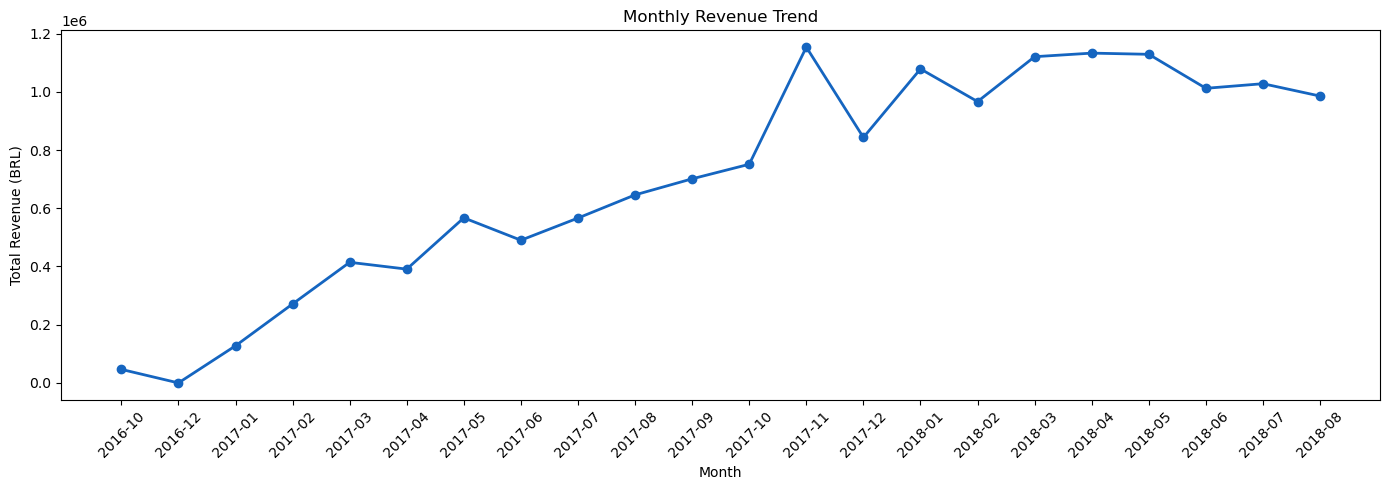

=== Monthly Revenue ===
   order_month  payment_value
0      2016-10       46566.71
1      2016-12          19.62
2      2017-01      127545.67
3      2017-02      271298.65
4      2017-03      414369.39
5      2017-04      390952.18
6      2017-05      567066.73
7      2017-06      490225.60
8      2017-07      566403.93
9      2017-08      646000.61
10     2017-09      701169.99
11     2017-10      751140.27
12     2017-11     1153528.05
13     2017-12      843199.17
14     2018-01     1078606.86
15     2018-02      966510.88
16     2018-03     1120678.00
17     2018-04     1132933.95
18     2018-05     1128836.69
19     2018-06     1012090.68
20     2018-07     1027903.86
21     2018-08      985414.28


In [218]:
# Aggregate sales_df by month — already clean (delivered, deduplicated, revenue summed per order)
# One preparation serves both trend and seasonality — no redundant joins needed
sales_df['order_purchase_timestamp'] = pd.to_datetime(sales_df['order_purchase_timestamp'])
sales_df['order_month'] = sales_df['order_purchase_timestamp'].dt.to_period('M')

monthly_revenue = sales_df.groupby('order_month')['payment_value'].sum().reset_index()
monthly_revenue['order_month'] = monthly_revenue['order_month'].astype(str)

# Line plot: best for continuous time-series — shows direction, slope, and turning points
plt.figure(figsize=(14, 5))
plt.plot(monthly_revenue['order_month'], monthly_revenue['payment_value'],
         marker='o', color='#1565C0', linewidth=2)
plt.xticks(rotation=45)
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue (BRL)')
plt.tight_layout()
plt.show()

print("=== Monthly Revenue ===")
print(monthly_revenue.to_string())

#### Monthly Revenue Trend
- Revenue started very low in late 2016, showing the platform was in its early stage.
- Strong and consistent growth throughout 2017, from ~127K in January to ~751K by October.
- A sharp spike in 2017-11 (1.15M BRL) — the highest month in the dataset.
- A drop in 2017-12 (~843K), followed by recovery and stabilization in 2018 between ~966K–1.13M BRL.
- Slight softening in mid-2018 (Jun–Aug), though this may reflect dataset truncation rather than a real decline.

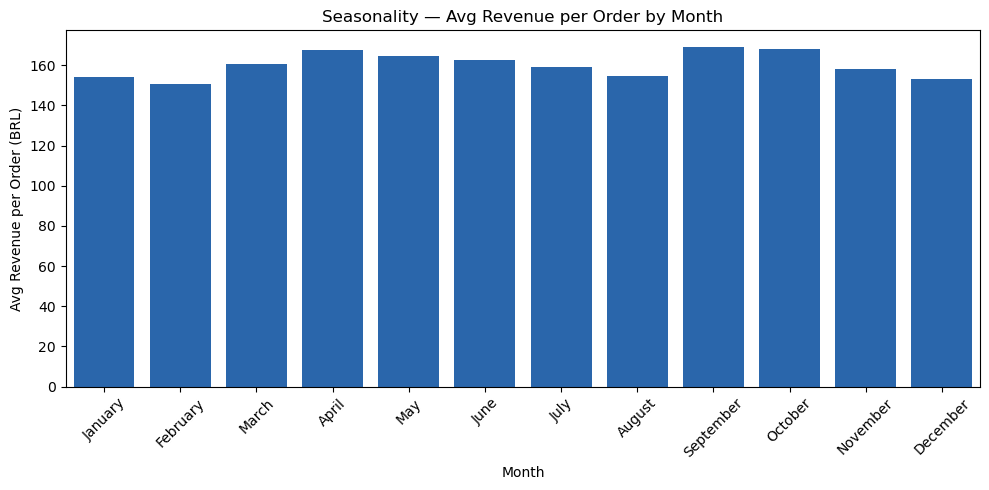


=== Seasonality Averages ===
   month_label  payment_value
0      January     154.259180
1     February     150.805255
2        March     160.754780
3        April     167.441614
4          May     164.730784
5         June     162.693987
6         July     158.938071
7       August     154.724477
8    September     168.956624
9      October     168.186165
10    November     158.256009
11    December     152.923248


In [219]:
import calendar

# Group by month-of-year and take mean (not sum)
# Mean isolates the seasonal signal regardless of how many years exist per month
sales_df['month_num'] = sales_df['order_purchase_timestamp'].dt.month
seasonality = sales_df.groupby('month_num')['payment_value'].mean().reset_index()
seasonality['month_label'] = seasonality['month_num'].apply(
    lambda x: calendar.month_name[x]
)

# Bar plot: best for comparing discrete month categories
month_order = list(calendar.month_name)[1:]
plt.figure(figsize=(10, 5))
sns.barplot(
    data=seasonality,
    x='month_label',
    y='payment_value',
    order=month_order,
    color='#1565C0'
)
plt.title('Seasonality — Avg Revenue per Order by Month')
plt.xlabel('Month')
plt.ylabel('Avg Revenue per Order (BRL)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\n=== Seasonality Averages ===")
print(seasonality[['month_label', 'payment_value']].to_string())

#### Seasonality: Avg Revenue per Order

- The range is very narrow: 150.8 (February) to 169.0 (September) - only an ~18 BRL spread across the entire year.
- September and October have the highest average order values (168–169 BRL).
- February and December are the lowest (150–153 BRL).
- Seasonal variation in spend per order is minimal as customers consistently spend at roughly the same level regardless of month.

#### Summary Insight: Time Analysis

Olist's revenue growth was driven by increasing order volume, not by customers spending more per order. Average order value is remarkably stable year-round (±18 BRL). The business scaled ~20x from launch to plateau in under two years, with 2017-11 standing out as the single peak month. By 2018, revenue stabilized at a new high plateau of ~1M+ BRL/month.

 ---------------------------------------
### **III. Product Analysis**
 ---------------------------------------
**Business Question:** Which categories should receive prioritized inventory, marketing spend, and logistics investment — based on revenue efficiency vs. volume?

In [220]:
# used Single approach: merged order_items, products, category_translation
# since order_items has revenue (price) and volume (order_item_id count)
# products links product_id to category
# translation converts Portuguese category names to English
# One merged df serves both revenue + volume analysis(no separate joins needed)

product_df = order_items.merge(products[['product_id', 'product_category_name']], 
                                on='product_id', how='left')

product_df = product_df.merge(category_translation, 
                               on='product_category_name', how='left')

# Fill untranslated categories with original Portuguese name. doing so, avoids losing valid rows just because translation is missing
product_df['category'] = product_df['product_category_name_english'].fillna(
    product_df['product_category_name']
)


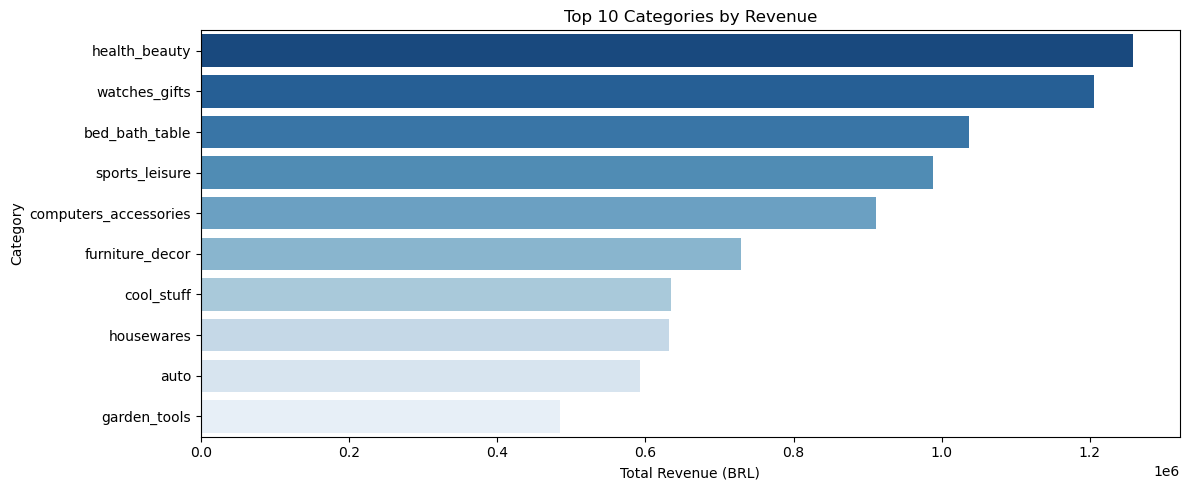

=== Top 10 by Revenue ===
                category       price
0          health_beauty  1258681.34
1          watches_gifts  1205005.68
2         bed_bath_table  1036988.68
3         sports_leisure   988048.97
4  computers_accessories   911954.32
5        furniture_decor   729762.49
6             cool_stuff   635290.85
7             housewares   632248.66
8                   auto   592720.11
9           garden_tools   485256.46


In [221]:
# Top 10 Categories by Revenue — sum of price per category
# Horizontal bar: optimal for ranked categorical labels with long names
revenue_by_cat = (
    product_df.groupby('category')['price']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(12, 5))
sns.barplot(
    data=revenue_by_cat,
    x='price',
    y='category',
    hue='category',
    palette=sns.color_palette("Blues_r", n_colors=len(revenue_by_cat)),
    legend=False
)
plt.title('Top 10 Categories by Revenue')
plt.xlabel('Total Revenue (BRL)')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

print("=== Top 10 by Revenue ===")
print(revenue_by_cat.to_string())

#### health_beauty Leads Revenue at BRL 1.26M — Pricing Power Drives the Top 2

- **health_beauty** (1.26M) and **watches_gifts** (1.21M) lead by a significant margin — both are high unit-price categories where revenue is generated from fewer but more valuable transactions.
- **bed_bath_table**, **sports_leisure**, and **computers_accessories** form a solid mid-tier (900K–1.04M BRL).
- **furniture_decor** through **garden_tools** trail at 485K–730K BRL — volume contributors rather than revenue leaders.

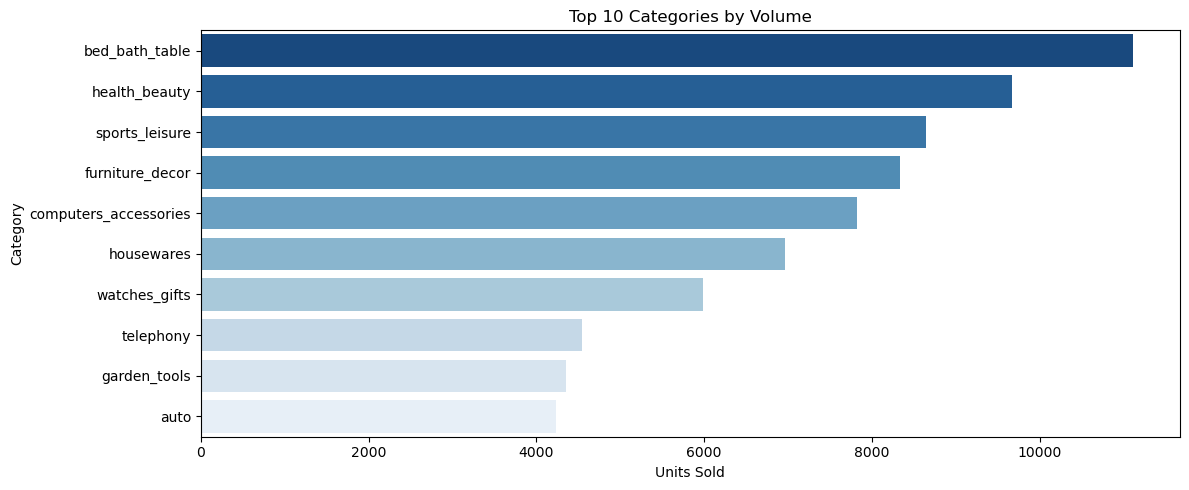


=== Top 10 by Volume ===
                category  units_sold
0         bed_bath_table       11115
1          health_beauty        9670
2         sports_leisure        8641
3        furniture_decor        8334
4  computers_accessories        7827
5             housewares        6964
6          watches_gifts        5991
7              telephony        4545
8           garden_tools        4347
9                   auto        4235


In [222]:
# Top 10 Categories by Volume — units sold per category
# Separated from revenue: high-volume categories may have low price per unit
volume_by_cat = (
    product_df.groupby('category')['order_item_id']
    .count()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
    .rename(columns={'order_item_id': 'units_sold'})
)

plt.figure(figsize=(12, 5))
sns.barplot(
    data=volume_by_cat,
    x='units_sold',
    y='category',
    hue='category',
    palette=sns.color_palette("Blues_r", n_colors=len(volume_by_cat)),
    legend=False
)
plt.title('Top 10 Categories by Volume')
plt.xlabel('Units Sold')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

print("\n=== Top 10 by Volume ===")
print(volume_by_cat.to_string())

#### bed_bath_table Leads Volume at 11,115 Units — watches_gifts Reveals Pricing Power Gap

- **bed_bath_table** leads volume (11,115 units) but ranks 3rd in revenue — high turnover, lower price per unit.
- **health_beauty** (9,670 units) is the only category in the top 2 for both revenue and volume — uniquely balanced.
- **watches_gifts** ranks 2nd in revenue but 7th in volume (~6K units) — generates outsized revenue from fewer transactions, indicating strong pricing power.
- **telephony** appears in the volume top 10 but not in the revenue top 10 — high quantity, low margin per unit.

### Summary Insight — Product Analysis

Two distinct category archetypes coexist on the platform: **revenue-efficient** categories (watches_gifts: high price, low volume) and **volume-driven** categories (bed_bath_table: high volume, lower margin). health_beauty is the standout — it is the only category ranking top-2 in both dimensions, making it the lowest-risk category for sustained growth investment.

**✅ Recommendation:** Prioritize health_beauty for inventory depth, promotional spend, and seller acquisition. It is the only category that does not require a trade-off between revenue per unit and total units sold.

 ------------------------------------
### **IV. Payment Analysis**
 ------------------------------------
**Business Question:** Does the current payment infrastructure serve all customer segments, and are installment structures aligned with observed purchasing behavior?

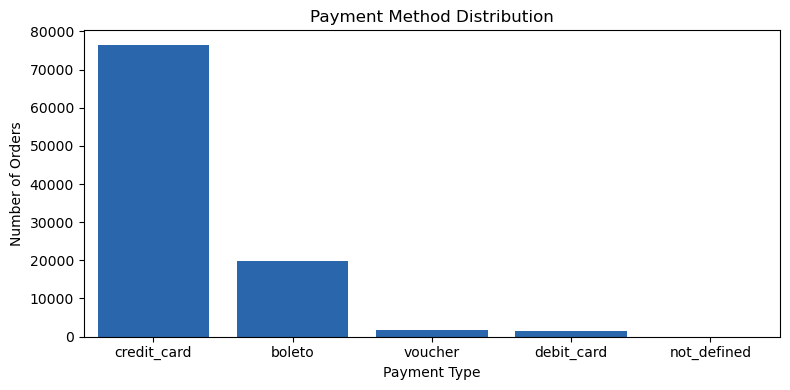

=== Payment Methods ===
  payment_type  order_count
0  credit_card        76476
1       boleto        19783
2      voucher         1621
3   debit_card         1477
4  not_defined            3


In [223]:
# Payment Methods — use payment_sequential==1 to avoid counting split payments as separate orders
payment_methods = (payments[payments['payment_sequential'] == 1]
                   .groupby('payment_type')['order_id']
                   .count()
                   .sort_values(ascending=False)
                   .reset_index()
                   .rename(columns={'order_id': 'order_count'}))

plt.figure(figsize=(8, 4))
sns.barplot(
    data=payment_methods,
    x='payment_type',
    y='order_count',
    color='#1565C0'   # single blue color
)
plt.title('Payment Method Distribution')
plt.xlabel('Payment Type')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()

print("=== Payment Methods ===")
print(payment_methods.to_string())

#### Credit Card Captures 77% of Transactions — Boleto Retains a Structurally Distinct 20%

- **Credit card dominates** with 76,476 orders (~77%) — the primary revenue channel.
- **Boleto accounts for 20% (19,783 orders)** — not a marginal segment. Boleto is a Brazil-specific bank-slip payment used by customers who are unbanked or prefer cash-based transactions. Removing it would exclude 1 in 5 customers.
- **Voucher (1,621) and debit card (1,477)** are marginal at ~3% combined.
- **not_defined (3)** is negligible — likely a system-level data entry artifact.

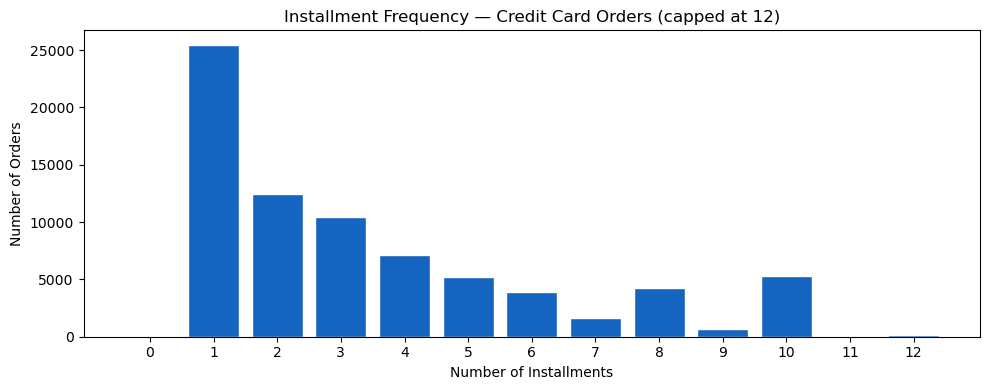


=== Installment Distribution (Credit Card) ===
    payment_installments  order_count
0                      0            2
1                      1        25455
2                      2        12413
3                      3        10461
4                      4         7098
5                      5         5239
6                      6         3920
7                      7         1626
8                      8         4268
9                      9          644
10                    10         5328
11                    11           23
12                    12          133
13                    13           16
14                    14           15
15                    15           74
16                    16            5
17                    17            8
18                    18           27
19                    20           17
20                    21            3
21                    22            1
22                    23            1
23                    24           18


In [224]:
# Installment behavior — credit card only
# boleto/voucher are structurally single-installment — filtering prevents misleading the chart
installments = (payments[payments['payment_type'] == 'credit_card']
                .groupby('payment_installments')['order_id']
                .count()
                .reset_index()
                .rename(columns={'order_id': 'order_count'}))

# Cap at 12 for readability — installments 13-24 are rare (<300 orders total)
inst_plot = installments[installments['payment_installments'] <= 12].copy()

plt.figure(figsize=(10, 4))
plt.bar(
    inst_plot['payment_installments'],
    inst_plot['order_count'],
    color='#1565C0',
    edgecolor='white'
)
plt.title('Installment Frequency — Credit Card Orders (capped at 12)')
plt.xlabel('Number of Installments')
plt.ylabel('Number of Orders')
plt.xticks(range(0, 13))
plt.tight_layout()
plt.show()

print("\n=== Installment Distribution (Credit Card) ===")
print(installments.to_string())

#### Installment Behavior (Credit Card Only)

- 1 installment is by far the most common (25,455 orders) — meaning most customers prefer to pay in full.
- Installments 2–6 show a steady decline: 12,413 → 3,920, reflecting a natural drop-off as plans get longer.
- Notable spikes at 8 (4,268) and 10 (5,328) — these stand out above the declining trend, suggesting these are specific plan options actively offered or promoted by the platform.
- Installments beyond 12 are rare (under 200 orders each) — long-term credit plans exist but are rarely used.

#### Summary Insight — Payment Analysis

Credit card is the overwhelmingly preferred channel at 77%, and within that, most customers pay in full (1 installment) or use short plans (2–6). The spikes at 8 and 10 installments are structured plan offerings, not organic customer behavior — they represent engineered purchase-enabling tools for higher-value transactions. Boleto's 20% share is structurally significant, not incidental.

**✅ Recommendation:** Retain boleto as a first-class payment option. The 8- and 10-installment spikes suggest that promoting specific structured plans for higher-value categories (watches_gifts, computers_accessories) could lift AOV without requiring price increases.

 ---------------------------------------
### **V. Customer Satisfaction**
 ---------------------------------------
**Business Question:** What operational variable most directly predicts a 1-star review — and how large is the measurable gap between satisfied and dissatisfied customers?

In [225]:
# merge reviews with orders since reviews has scores, orders has delivery timestamps
# both needed to analyze score distribution + delivery time vs score relationship

satisfaction_df = reviews.merge(
    orders[['order_id', 'delivery_days']].dropna(),
    on='order_id', how='inner'
)

# -------------------Review Score Distribution----------------------
# Simple value_counts is enough — 5 discrete scores (1-5)
score_dist = (satisfaction_df['review_score']
              .value_counts()
              .sort_index()
              .reset_index()
              .rename(columns={'review_score': 'score', 'count': 'order_count'}))

score_dist['percentage'] = (score_dist['order_count'] / 
                             score_dist['order_count'].sum() * 100).round(2)

# Print outputs
print("=== Review Score Distribution ===")
print(score_dist.to_string())
print("\n=== Avg Delivery Days by Review Score ===")
print(satisfaction_df.groupby('review_score')['delivery_days']
      .mean().round(2).reset_index().to_string())

=== Review Score Distribution ===
   score  order_count  percentage
0      1         9409        9.76
1      2         2941        3.05
2      3         7962        8.26
3      4        18987       19.70
4      5        57060       59.22

=== Avg Delivery Days by Review Score ===
   review_score  delivery_days
0             1          20.85
1             2          16.19
2             3          13.80
3             4          11.85
4             5          10.22


#### 79% Positive Rate Masks a Polarization Problem: Score 1 Is 3× Higher Than Score 2

- **Score 5 dominates at 59.22%** — strong base satisfaction.
- **Scores 4+5 combined: 78.92%** — the majority of customers are satisfied.
- **Score 1 at 9.76% is disproportionately high** relative to score 2 (3.05%) and score 3 (8.26%). This is a classic failure-mode polarization: when the experience breaks down, customers do not give moderate scores — they go straight to the floor.
- The 9.76% score-1 rate is the primary retention risk metric in this dataset.

#### 2× Delivery Gap: Score-1 Customers Waited Twice as Long as Score-5

- **Score 1 avg: 20.85 days** vs **Score 5 avg: 10.22 days** — a 2× difference driven purely by delivery speed.
- The relationship is monotonic: each score level corresponds to a progressively faster delivery time, with no reversals. Delivery time is a continuous predictor of satisfaction, not a threshold effect.
- Every 5 additional days of delivery time corresponds to approximately one full star of satisfaction loss.

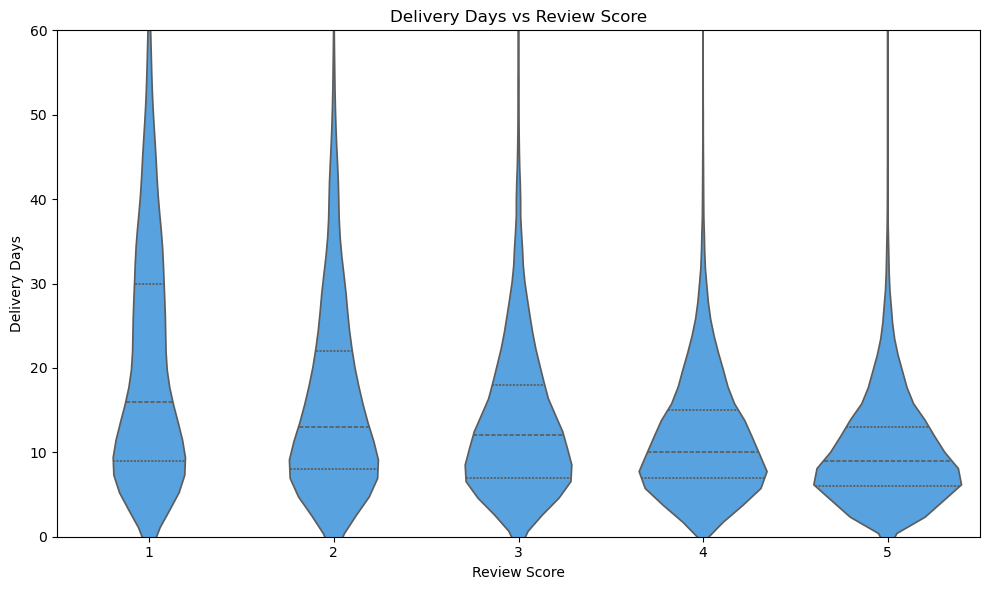

In [226]:
# Violin plot: reveals full distribution shape per score group
# More informative than boxplot — shows density concentration, not just quartiles
# inner='quartile' overlays median and IQR inside each violin
plt.figure(figsize=(10, 6))
sns.violinplot(
    data=satisfaction_df,
    x='review_score',
    y='delivery_days',
    inner='quartile',
    color="#42A5F5"
)
plt.title('Delivery Days vs Review Score')
plt.xlabel('Review Score')
plt.ylabel('Delivery Days')
plt.ylim(0, 60)  # cap at 60 to reduce extreme outlier distortion
plt.tight_layout()
plt.show()

#### Consistency Predicts Satisfaction as Strongly as Speed

- **Score 1** has the widest violin — delivery days spread broadly from near-0 to 60+, confirming that both genuinely late deliveries AND some fast-but-disappointing deliveries contribute to 1-star outcomes (product/quality issues coexist with logistics failures).
- **Score 5** is the narrowest and most compact violin — tight concentration between 5–13 days. Fast AND consistent delivery is the score-5 signature.
- **Score-5 delivery distribution is ~2.4× narrower than Score-1** — consistency is a stronger predictor of top satisfaction than raw speed alone.
- Scores 2–4 show a progressive narrowing and downward shift, confirming the monotonic relationship.

#### Summary Insight — Customer Satisfaction

Delivery speed is the primary driver of review score: customers receiving orders in ~10 days give 5 stars; those waiting ~21 days give 1 star. The violin analysis adds a critical nuance — it is not only about speed, it is about consistency. Score-5 deliveries are both fast and tightly distributed.

**✅ Recommendation:** Establish a delivery consistency SLA: flag any order with delivery variance >2 standard deviations from the mean as an operational alert — before the review is submitted, not after. The 9.76% score-1 rate is not a satisfaction problem; it is a predictable logistics outcome that can be monitored and reduced.

 ---------------------------------------
### **VI. Delivery Performance**
 ---------------------------------------
**Business Question:** Is the platform's delivery reliability improving over time, and where is operational risk most concentrated — in average performance or in the extreme tail?

In [227]:
# Filter and Core Stats
# Delivered orders only — performance must be measured on completed deliveries
# describe() gives full picture before extracting individual KPIs
delivery_df = orders[orders["order_status"] == "delivered"].copy()
delivery_df[["delivery_days", "delay_days"]].describe().round(2)

,delivery_days,delay_days
count,96470.00,96470.00
mean,12.09,-11.88
std,9.55,10.18
min,0.00,-147.00
25%,6.00,-17.00
50%,10.00,-12.00
75%,15.00,-7.00
max,209.00,188.00


In [228]:
# Core Delivery Metrics
# Average Delivery Time: Measures overall speed of delivery operations.
# Late Delivery Percentage: Measures reliability and customer satisfaction risk.
# Justification: These KPIs are single summary metrics no visualization needed.

avg_delivery_time = delivery_df["delivery_days"].mean()
late_percentage = (delivery_df["delay_days"] > 0).mean() * 100

print("Average Delivery Time:", round(avg_delivery_time, 2), "days")
print("Late Delivery Percentage:", round(late_percentage, 2), "%")

Average Delivery Time: 12.09 days
Late Delivery Percentage: 6.77 %


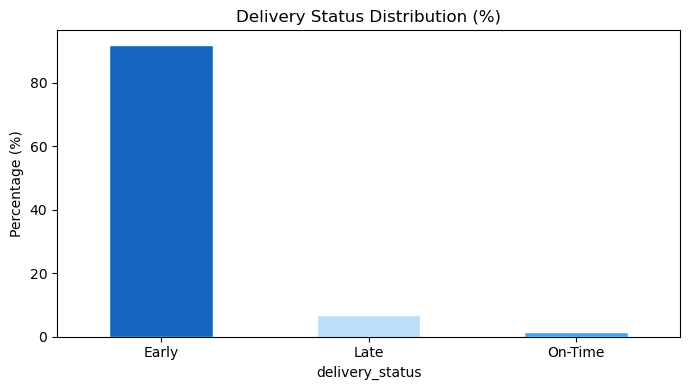

delivery_status
Early      91.89
Late        6.77
On-Time     1.34
Name: proportion, dtype: float64


In [229]:
# Early / On-Time / Late classification
delivery_df["delivery_status"] = delivery_df["delay_days"].apply(
    lambda x: "Late" if x > 0 else ("On-Time" if x == 0 else "Early")
)

status_pct = delivery_df["delivery_status"].value_counts(normalize=True) * 100

# Blue family: dark = Early (best outcome), mid = On-Time, light = Late
blue_colors = {
    "Early":   "#1565C0",
    "On-Time": "#42A5F5",
    "Late":    "#BBDEFB"
}

plt.figure(figsize=(7, 4))
status_pct.sort_index().plot(
    kind="bar",
    color=[blue_colors[x] for x in status_pct.sort_index().index],
    edgecolor="white"
)
plt.title("Delivery Status Distribution (%)")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(status_pct.round(2))

#### 92% Early Deliveries Is a Strategy, Not Luck — But Only 1% Hit the Estimate Exactly

- **91.89% of orders arrived Early** — direct result of conservative delivery estimates set ~12 days beyond actual delivery time. The platform systematically underpromises.
- **6.77% Late** — small but operationally significant; as established in Section V, late deliveries are the primary driver of 1-star reviews.
- **1.34% On-Time** — almost no orders hit the estimated date exactly, confirming the estimate is not a precision target but a buffer mechanism.

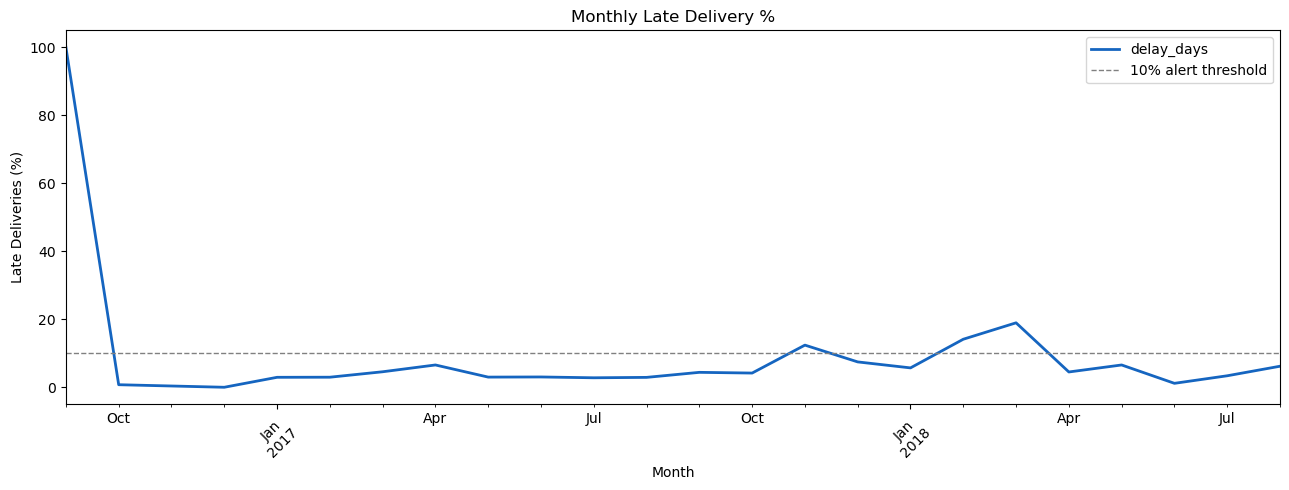

=== Monthly Late Delivery % ===
purchase_month
2016-09    100.00
2016-10      0.75
2016-12      0.00
2017-01      2.93
2017-02      2.96
2017-03      4.56
2017-04      6.56
2017-05      2.99
2017-06      3.03
2017-07      2.79
2017-08      2.91
2017-09      4.39
2017-10      4.18
2017-11     12.40
2017-12      7.46
2018-01      5.70
2018-02     14.13
2018-03     18.96
2018-04      4.50
2018-05      6.56
2018-06      1.16
2018-07      3.38
2018-08      6.19
Freq: M


In [230]:
# Monthly Late % over Time — line plot best for trend detection
# Reveals if late delivery rate is improving, degrading, or seasonal
delivery_df["purchase_month"] = pd.to_datetime(
    delivery_df["order_purchase_timestamp"]).dt.to_period("M")

monthly_late = (delivery_df.groupby("purchase_month")["delay_days"]
                .apply(lambda x: (x > 0).mean() * 100)
                .round(2))

plt.figure(figsize=(13, 5))
monthly_late.plot(color='#1565C0', linewidth=2)
plt.axhline(y=10, color='gray', linestyle='--', linewidth=1, label='10% alert threshold')
plt.title("Monthly Late Delivery %")
plt.ylabel("Late Deliveries (%)")
plt.xlabel("Month")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("=== Monthly Late Delivery % ===")
print(monthly_late.to_string())

#### 2018 Q1 Is the Only Structural Risk Event — Late Rate Peaked at 19% in March

- **2016-09 at 100%** is a data artifact — the platform had just launched with near-zero order volume. Not operationally meaningful.
- **2017: late rate held below 7%** for most months — the conservative estimation strategy was working.
- **2017-11 spike to 12.4%** followed by recovery — consistent with a single high-volume month straining logistics capacity.
- **2018-02 through 2018-03 peaked at 19%** — the only sustained operational failure in the dataset. Two consecutive months above the 10% threshold signal a systemic issue, not a one-off event.
- **2018-04 onwards: recovery to below 7%** — the platform self-corrected, but the satisfaction damage from those months is already reflected in the Section V review scores.

#### Summary Insight — Delivery Performance

Olist's delivery strategy is built on deliberate underpromising: setting estimates ~12 days beyond actual delivery creates a 92% early rate that protects customer satisfaction. The 6.77% overall late rate is manageable, but the 2018 Q1 spike to ~19% for two consecutive months demonstrates that the buffer has a breaking point. When it breaks, the satisfaction impact is immediate and measurable — exactly as shown in Section V.

**✅ Recommendation:** Implement a 10% monthly late delivery rate as an operational alert threshold — the 10% reference line added to the chart above. Any month crossing this threshold warrants a logistics audit before the following month's orders ship. The 2018 Q1 data shows that two consecutive months above threshold produce satisfaction damage that takes 3+ months to reverse.

 ------------------------------------
# **What the Data Is Really Saying**
 ------------------------------------

Olist scaled revenue 20× in two years without meaningfully increasing what customers spend per order — every unit of growth came from acquiring more customers, not extracting more from existing ones. That model is sustainable only as long as the customer experience holds. The data reveals a single operational chain connecting everything:

> **Delivery speed → Satisfaction → Review score → Repeat purchase → Revenue**

With 92% of orders arriving early and a stable 6.77% late rate, the platform has built a strong reliability buffer. But the 2018 Q1 spike to ~19% late deliveries — sustained across two consecutive months — shows exactly what happens when that buffer fails: satisfaction scores degrade, 1-star reviews concentrate, and the retention engine stalls.

**health_beauty's dominance** across both revenue and volume, **credit card's 77% share**, and the conservative delivery estimation strategy all confirm the same thing: Olist has found a formula that works at scale. The analysis quantifies the cost of breaking it.

| If late rate exceeds 10% | Score-1 reviews increase | Revenue growth stalls |
|--------------------------|--------------------------|----------------------|
| 2018 Q1 proved it | Section V quantified it | Section II shows the plateau |

The single most important operational metric in this business is not revenue, AOV, or category mix. **It is the monthly late delivery rate.** Everything else follows from it.